In [44]:
import os
import mne
import numpy as np
import pywt
import matplotlib.pyplot as plt

# 基础目录配置
BASE_DIR = './eeg_classification_data'
SUB_DIRS = {
    'train': os.path.join(BASE_DIR, 'train'),
    'val': os.path.join(BASE_DIR, 'val')
}

# 创建对应的子文件夹：seizure (发作) 和 normal (正常)
for mode in ['train', 'val']:
    for label in ['seizure', 'normal']:
        path = os.path.join(SUB_DIRS[mode], label)
        os.makedirs(path, exist_ok=True)

print("目录结构已就绪：./eeg_classification_data/train 和 ./eeg_classification_data/val")

目录结构已就绪：./eeg_classification_data/train 和 ./eeg_classification_data/val


In [45]:
def generate_and_save_cwt(data, fs, save_path):
    scales = np.arange(1, 128)
    # 使用 Morlet 小波进行连续小波变换
    coef, freqs = pywt.cwt(data, scales, 'morl', sampling_period=1/fs)
    
    fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100) # 对应 224x224 像素
    ax.imshow(np.abs(coef), aspect='auto', cmap='jet')
    ax.axis('off')
    plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
    
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

def process_edf_to_images(file_path, seizure_start, seizure_end, target_dir, num_samples=50, window_sec=3):
    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
    # 选取第一个通道 (FP1-F7)
    data, times = raw[0, :]
    data = data.flatten()
    fs = int(raw.info['sfreq'])
    win_samples = window_sec * fs
    
    # 1. 提取并保存发作期图像 (Seizure)
    print(f"正在从 {file_path} 处理发作期数据...")
    seizure_data = data[seizure_start * fs : seizure_end * fs]
    for i in range(min(num_samples, len(seizure_data)//win_samples)):
        segment = seizure_data[i*win_samples : (i+1)*win_samples]
        save_path = os.path.join(target_dir, 'seizure', f'sz_{i}.png')
        generate_and_save_cwt(segment, fs, save_path)
        
    # 2. 提取并保存正常期图像 (Normal)
    # 我们取文件开头远离发作的时间段（例如前 500 秒）
    print(f"正在从 {file_path} 处理正常期数据...")
    normal_data = data[0 : 500 * fs]
    for i in range(num_samples):
        segment = normal_data[i*win_samples : (i+1)*win_samples]
        save_path = os.path.join(target_dir, 'normal', f'nr_{i}.png')
        generate_and_save_cwt(segment, fs, save_path)

In [46]:
# 根据 summary.txt：chb08_02 发作时间为 2670-2841 秒
process_edf_to_images(
    file_path='chb08_02.edf',
    seizure_start=2670,
    seizure_end=2841,
    target_dir=SUB_DIRS['train'],
    num_samples=50
)
print("训练集（Record 02）生成完毕。")

C:\Users\29281\AppData\Local\Temp\ipykernel_20752\387774905.py:15: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


正在从 chb08_02.edf 处理发作期数据...
正在从 chb08_02.edf 处理正常期数据...
训练集（Record 02）生成完毕。


In [47]:
# 根据 summary.txt：chb08_13 发作时间为 2417-2577 秒
process_edf_to_images(
    file_path='chb08_13.edf',
    seizure_start=2417,
    seizure_end=2577,
    target_dir=SUB_DIRS['val'],
    num_samples=50
)
print("验证集（Record 13）生成完毕。")

正在从 chb08_13.edf 处理发作期数据...


C:\Users\29281\AppData\Local\Temp\ipykernel_20752\387774905.py:15: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


正在从 chb08_13.edf 处理正常期数据...
验证集（Record 13）生成完毕。


In [48]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# 加载训练集：来自文件夹 A
train_ds = image_dataset_from_directory(
    SUB_DIRS['train'],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# 加载验证集：来自文件夹 B
val_ds = image_dataset_from_directory(
    SUB_DIRS['val'],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # 验证集通常不打乱以便观察
)

# 归一化处理
def preprocess(image, label):
    return image / 255.0, label

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)

print("数据管道已建立。验证集与训练集已实现物理隔离。")

Found 100 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
数据管道已建立。验证集与训练集已实现物理隔离。


In [49]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. 构建 CNN 架构
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Dropout 用于防止过拟合
    layers.Dense(1, activation='sigmoid') # 二分类：0(正常) 或 1(癫痫)
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 2. 训练模型 (记录历史数据用于可视化)
print("开始训练模型...")
EPOCHS = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# 保存模型权重
model.save('eeg_cwt_seizure_classifier.h5')
print("模型训练完成并已保存。")

开始训练模型...
Epoch 1/15


D:\py\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 271ms/step - accuracy: 0.5156 - loss: 2.6298 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - accuracy: 0.4666 - loss: 0.6909 - val_accuracy: 0.5200 - val_loss: 0.6860
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 0.5756 - loss: 0.6745 - val_accuracy: 0.5100 - val_loss: 0.6812
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - accuracy: 0.7164 - loss: 0.6095 - val_accuracy: 0.5400 - val_loss: 0.6702
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.6329 - loss: 0.6492 - val_accuracy: 0.5400 - val_loss: 0.6782
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 273ms/step - accuracy: 0.6302 - loss: 0.6584 - val_accuracy: 0.6100 - val_loss: 0.6643
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.7187 - loss: 0.6272 - val_accuracy: 0.6300 - val_loss: 0.6516
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.6792 - loss: 0.5361 - val_accuracy: 0.6200 - val_loss: 0.6738
Epo

模型训练完成并已保存。


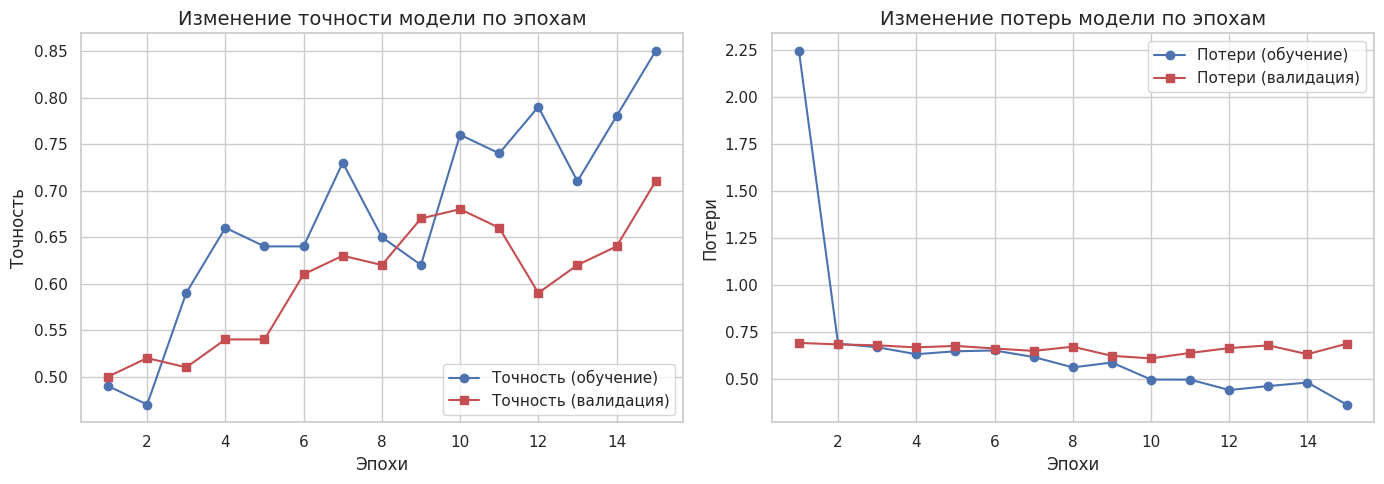

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置学术风格的绘图参数
sns.set_theme(style="whitegrid")
# 使用支持西里尔字母的默认字体
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

# 准确率曲线
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b-o', label='Точность (обучение)') # 训练集准确率
plt.plot(epochs_range, val_acc, 'r-s', label='Точность (валидация)') # 验证集准确率
plt.title('Изменение точности модели по эпохам', fontsize=14) # 模型准确率随 Epoch 的变化
plt.xlabel('Эпохи') # Epochs
plt.ylabel('Точность') # Accuracy
plt.legend(loc='lower right')

# 损失曲线
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b-o', label='Потери (обучение)') # 训练集损失
plt.plot(epochs_range, val_loss, 'r-s', label='Потери (валидация)') # 验证集损失
plt.title('Изменение потерь модели по эпохам', fontsize=14) # 模型损失随 Epoch 的变化
plt.xlabel('Эпохи') # Epochs
plt.ylabel('Потери') # Loss
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

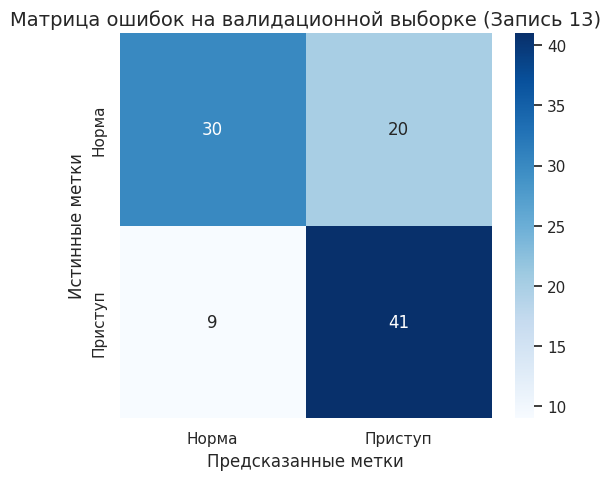


=== Отчет об оценке классификации ===
              precision    recall  f1-score   support

       Норма       0.77      0.60      0.67        50
     Приступ       0.67      0.82      0.74        50

    accuracy                           0.71       100
   macro avg       0.72      0.71      0.71       100
weighted avg       0.72      0.71      0.71       100



In [51]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 获取验证集的真实标签和预测结果
y_true = []
y_pred_probs = []

# 遍历验证集数据管道
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

# 绘制混淆矩阵
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Норма', 'Приступ'], # 正常, 发作
            yticklabels=['Норма', 'Приступ']) # 正常, 发作
plt.title('Матрица ошибок на валидационной выборке (Запись 13)', fontsize=14) # 验证集混淆矩阵
plt.ylabel('Истинные метки') # 真实标签
plt.xlabel('Предсказанные метки') # 预测标签
plt.show()

# 打印详细的分类报告 (终端输出也修改为俄语，方便直接复制到文本报告中)
print("\n=== Отчет об оценке классификации ===")
print(classification_report(y_true, y_pred, target_names=['Норма', 'Приступ']))